In [2]:
%run ./run_dino.ipynb

/home/finn/Documents/1-projects/Consulting-Project-simple-Prediction-Model/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Test dino on random image

In [3]:
# load image
img_path = r"test_image/tor-zum-32-marco-gruell-sv-werder-bremen-17-jubel-mit-der-mannschaft-ger-sv-werder-bremen-vs-1.jpg"
test_image = load_image(img_path)
print(f"Image loaded successfully")

# test
batch = make_transform()(test_image).unsqueeze(0)

print(batch.shape)

with torch.inference_mode():
    feats = dinov3_vits16.forward_features(batch) 

if isinstance(feats, dict):
    pooled_output = feats["x_norm_clstoken"]
    patch_tokens = feats["x_norm_patchtokens"]
else:
    # fallback if forward_features() not implemented
    tokens = model(batch) 
    pooled_output = tokens[:,0]          
    patch_tokens = tokens[:,1+model.num_register_tokens:,:]

pooled_output.shape

Image loaded successfully
torch.Size([1, 3, 256, 256])


torch.Size([1, 384])

## Test wether slicing works

In [14]:
path_to_image = "../data/rip_frac/ribfrac-val-images/RibFrac421-image.nii.gz"
ct_img = nii_img_to_tensor(path_to_image)
print(ct_img.shape)

Original spacing: x=0.8789060115814209, y=0.8789060115814209, z=1.25
Target spacing: x=0.75, y=0.75, z=1.5
torch.Size([1, 1, 240, 480, 480])


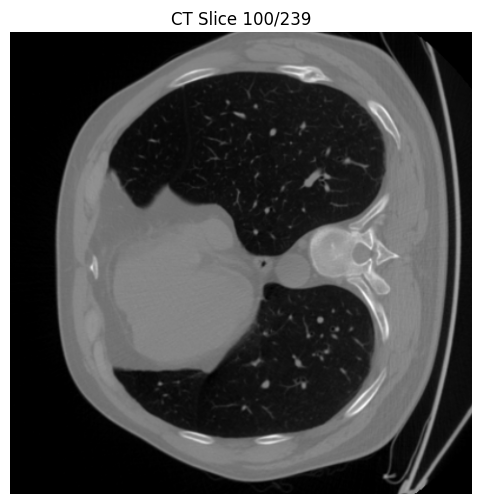

In [13]:
plot_ct_slice(ct_img, slice_index=100)

## Test wether dino functions are apllicable to sliced CTs and check dimensions

In [15]:
path_to_image = "../data/rip_frac/ribfrac-val-images/RibFrac421-image.nii.gz"
ct_img = nii_img_to_tensor(path_to_image)
print(ct_img.shape)
ct_slice = slice_ct(ct_img, slice_index=100)

Original spacing: x=0.8789060115814209, y=0.8789060115814209, z=1.25
Target spacing: x=0.75, y=0.75, z=1.5
torch.Size([1, 1, 240, 480, 480])


In [7]:
resize_size = 256
to_tensor = v2.ToImage()
resize = v2.Resize((resize_size, resize_size), antialias=True)
to_float = v2.ToDtype(torch.float32, scale=True)
normalize = v2.Normalize(
    mean=(0.485, 0.456, 0.406),
    std=(0.229, 0.224, 0.225),
)

transf = v2.Compose([to_tensor, resize, to_float, normalize])

In [8]:
# test run
ct_slice_latents = transf(ct_slice)
ct_slice_latents.shape

torch.Size([3, 256, 256])

In [9]:
# check dimensions of each step

print("Original dimension of one ct slice is:",ct_slice.shape)
transform1_ct_slice_= to_tensor(ct_slice)
print("After transforming to a tensor the dimesnions are:",transform1_ct_slice_.shape)
resize_ct_slice = resize(transform1_ct_slice_)
print("After resizing the dimensions are:", resize_ct_slice.shape)

print("Original dimension of one ct slice is:",ct_slice.shape)
transform1_ct_slice_= to_tensor(ct_slice)
print("After transforming to a tensor the dimesnions are:",transform1_ct_slice_.shape)
resize_ct_slice = resize(transform1_ct_slice_)
print("After resizing the dimensions are:", resize_ct_slice.shape)
resize_ct_slice_float = to_float(resize_ct_slice)
print("After turning into a float, the dimensions are:", resize_ct_slice_float.shape)

resize_ct_slice_float = resize_ct_slice_float.unsqueeze(0)


Original dimension of one ct slice is: (480, 480)
After transforming to a tensor the dimesnions are: torch.Size([1, 480, 480])
After resizing the dimensions are: torch.Size([1, 256, 256])
Original dimension of one ct slice is: (480, 480)
After transforming to a tensor the dimesnions are: torch.Size([1, 480, 480])
After resizing the dimensions are: torch.Size([1, 256, 256])
After turning into a float, the dimensions are: torch.Size([1, 256, 256])


In [10]:
# apllying transformation function
print(ct_slice.shape)
ct_slice_latents = make_transform()(ct_slice).unsqueeze(0)
print(ct_slice_latents.shape)

with torch.inference_mode():
    feats = dinov3_vits16.forward_features(ct_slice_latents) 

if isinstance(feats, dict):
    pooled_output = feats["x_norm_clstoken"]
    patch_tokens = feats["x_norm_patchtokens"]
else:
    # fallback if forward_features() not implemented
    tokens = model(ct_slice_latents) 
    pooled_output = tokens[:,0]          
    patch_tokens = tokens[:,1+model.num_register_tokens:,:]

print(pooled_output.shape)
print(patch_tokens.shape)

(480, 480)
torch.Size([1, 3, 256, 256])
torch.Size([1, 384])
torch.Size([1, 256, 384])


## Test functions for ripfrac

In [ ]:
# global_latents, local_latents 
global_latents, local_latents = run_dino_on_single_img(ct_slice)

print(global_latents.shape, local_latents.shape)

<class 'torch.Tensor'>
torch.Size([1, 384]) torch.Size([1, 256, 384])


In [ ]:
# ct_img
global_latents_list = []
local_latents_list = []

for slice_index in range(ct_img.shape[2]):
    # extract slice
    ct_slice = slice_ct(ct_img, slice_index=slice_index)
    # create latents
    global_latents, local_latents = run_dino_on_single_img(ct_slice)
    # append latents of each step to one list
    global_latents_list.append(global_latents)
    local_latents_list.append(local_latents)

# stack python list to a one tensor
global_latents_stacked = torch.stack(global_latents_list)
local_latents_stacked = torch.stack(local_latents_list)
global_latents_mean = global_latents.mean(dim=0).unsqueeze(0)

#global_latents_stacked.shape
#global_latents_mean.shape

In [ ]:
base_path = "../data/rip_frac/ribfrac-val-images"
all_global_latents_list = []

# loop to extract all latents
for i in range(421, 501):
    print("load ct",{i} )
    # change path to extract latents for all 80 images
    path = os.path.join(base_path, f"RibFrac{i}-image.nii.gz")
    ct_img = nii_img_to_tensor(path)

    # get mean of latents over all slices
    mean_latents_single_ct = get_all_ct_latents(ct_img)[0].mean(dim=0)

    # append mean to latent list
    all_global_latents_list.append(mean_latents_single_ct)

all_latents = torch.stack(all_global_latents_list)

# Convert to numpy
ct_latents_np = all_latents.cpu().numpy() 

# save latents
np.savez_compressed("ct_latents.npz", ct_latents=ct_latents_np)

load ct {421}
Original spacing: x=0.8789060115814209, y=0.8789060115814209, z=1.25
Target spacing: x=0.75, y=0.75, z=1.5
Original shape: h=599, w=599, d=270
Target shape: h=480, w=480, d=240
load ct {422}
Original spacing: x=0.8359379768371582, y=0.8359379768371582, z=1.25
Target spacing: x=0.75, y=0.75, z=1.5
Original shape: h=570, w=570, d=267
Target shape: h=480, w=480, d=240
load ct {423}
Original spacing: x=0.6953125, y=0.6953125, z=1.0
Target spacing: x=0.75, y=0.75, z=1.5
Original shape: h=474, w=474, d=242
Target shape: h=480, w=480, d=240
load ct {424}
Original spacing: x=0.83984375, y=0.83984375, z=1.0
Target spacing: x=0.75, y=0.75, z=1.5
Original shape: h=573, w=573, d=272
Target shape: h=480, w=480, d=240
load ct {425}
Original spacing: x=0.8535159826278687, y=0.8535159826278687, z=1.25
Target spacing: x=0.75, y=0.75, z=1.5
Original shape: h=582, w=582, d=300
Target shape: h=480, w=480, d=240
load ct {426}
Original spacing: x=0.697265625, y=0.697265625, z=1.0
Target spacin

In [ ]:
get_latents_full_data(5)

Processing file 1/5: RibFrac421-image.nii.gz
Original spacing: x=0.8789060115814209, y=0.8789060115814209, z=1.25
Target spacing: x=0.75, y=0.75, z=1.5
Processing file 2/5: RibFrac422-image.nii.gz
Original spacing: x=0.8359379768371582, y=0.8359379768371582, z=1.25
Target spacing: x=0.75, y=0.75, z=1.5
Processing file 3/5: RibFrac423-image.nii.gz
Original spacing: x=0.6953125, y=0.6953125, z=1.0
Target spacing: x=0.75, y=0.75, z=1.5
Processing file 4/5: RibFrac424-image.nii.gz
Original spacing: x=0.83984375, y=0.83984375, z=1.0
Target spacing: x=0.75, y=0.75, z=1.5
Processing file 5/5: RibFrac425-image.nii.gz
Original spacing: x=0.8535159826278687, y=0.8535159826278687, z=1.25
Target spacing: x=0.75, y=0.75, z=1.5
✅ Finished: shape torch.Size([5, 1, 384])


tensor([[[ 0.3030, -0.0711, -0.0611,  ..., -0.1771,  0.1074,  0.2652]],

        [[ 0.3170, -0.1099, -0.0681,  ..., -0.1378,  0.1129,  0.2264]],

        [[ 0.2817, -0.2759, -0.0340,  ..., -0.1776,  0.0005,  0.2924]],

        [[ 0.2684, -0.2691, -0.0781,  ..., -0.1577,  0.0896,  0.2263]],

        [[ 0.2913, -0.1566, -0.0602,  ..., -0.1583,  0.0197,  0.2505]]])

In [11]:
latents = np.load("latents/ripfrac_validation_set_ct_latents.npz")
print(latents.files)
latents_arr = latents["ct_latents"]
latents_arr.shape 
latents_arr_2d = np.squeeze(arr, axis=1)
latents_df = pd.DataFrame(latents_arr_2d)
latents_df.head()

['ct_latents']


,0,1,2,3,4,5,6,7,8,9,...,374,375,376,377,378,379,380,381,382,383
0,0.129225,-0.258634,0.067112,-0.206779,0.320000,0.412797,0.638890,-0.574432,-0.497904,-0.051114,...,-0.335963,0.823316,0.447879,-0.037116,0.966386,-0.110389,0.439283,-0.129833,-0.063163,0.282510
1,0.122551,-0.263979,0.068929,-0.210505,0.320414,0.413493,0.637082,-0.576536,-0.502469,-0.056239,...,-0.336833,0.820385,0.445235,-0.042153,0.965945,-0.105842,0.441729,-0.131999,-0.064944,0.281534
2,0.124551,-0.265282,0.066446,-0.208557,0.322468,0.417302,0.636733,-0.577624,-0.502796,-0.055141,...,-0.335018,0.820266,0.446155,-0.043165,0.966252,-0.109987,0.441186,-0.131362,-0.068010,0.283302
3,0.123685,-0.265368,0.067854,-0.211147,0.320864,0.416651,0.639083,-0.572609,-0.504219,-0.057264,...,-0.336916,0.821788,0.446186,-0.042413,0.965416,-0.107551,0.439369,-0.131711,-0.067372,0.282045
4,0.126202,-0.260627,0.067943,-0.210842,0.320451,0.413065,0.640549,-0.575655,-0.503236,-0.051685,...,-0.335696,0.821262,0.445944,-0.037130,0.966764,-0.107085,0.439057,-0.131441,-0.063116,0.282722
